In [69]:
from multiprocessing import Pool
import subprocess
import yaml
import os
import sys
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
import tempfile
import copy
from datetime import datetime
import pandas as pd
from collections import Counter
import numpy as np
import threading
import time
source_path = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))
sys.path.append(source_path)

from sklearn.ensemble import GradientBoostingClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from sklearn.model_selection import GroupKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.utils import shuffle
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix
import seaborn as sns
from sklearn.metrics import classification_report
from sklearn.metrics import balanced_accuracy_score
from sklearn.metrics import roc_curve, auc
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss
from sklearn.isotonic import IsotonicRegression

from joblib import load
import warnings
warnings.filterwarnings("ignore")

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader

from PIL import Image, ImageDraw, ImageFont
import matplotlib.pyplot as plt
import cv2


In [163]:
selected_FE = 'resnet50' #'trocr-base-stage1'# 'clip-vit-large-patch14'#'DeiT-Tiny' #'resnet18'#'clip-vit-large-patch14'  # Example feature extractor, can be changed
custom_pretrained = 'original'  # 'original', 'contrastive', 'fine-tune','progressive
evaluation_mode =  'backbone_only' #'backbone_only' #full_model
huggingface = True
head_type = 'pytorch'  # 'sklearn' or 'pytorch' or none
use_test_private = True
selected_classification_head = 'MLPClassifier1' #'logreg' #'MLPClassifier2'#'MLPClassifier1'#'TransformerClassifier'#'1DCNNClassifier'#'MLPClassifier2'
lang_train= 'ar' #'ar' #if en only train on en, if ar only train on ar, if en+ar or '' train on both
lang_test = 'ar' #'ar' #if en only test on en, if ar only test on ar, if en+ar or '' test on both
lang_sub = '_'+lang_train if lang_train in ['en', 'ar'] else ''
lang_test_sub = '_'+lang_test if lang_test in ['en', 'ar'] else ''


#test_private = file_IO.load_preprocessed_files(kind, 'test')
model_parameters = {
    'n_neurons':256,
    'hidden_sizes': [16],  # Hidden sizes for MLPClassifier2
    'dropout':0.9,
    'with_input_norm': 'batch_norm',  # Whether to use input normalization 'batch_norm' , None
    'mean': None,  # Mean for input normalization
    'scale': None,  # Scale for input normalization
    'activation': 'relu'
}

#creating current directory where i will save evaluation results for the current model
#only one current folder for each model,custom_pretrained combination -> new results will overwrite these
if evaluation_mode == 'backbone_only':
    if custom_pretrained == 'original':
        base_dir=source_path + f'/outputs/online_deep_feature_extraction/{selected_FE}/representation_extraction/'
    else:
        base_dir=source_path + f'/outputs/online_deep_feature_extraction/{selected_FE}/{custom_pretrained}/'
    if head_type == 'sklearn':
        search_dir = base_dir+f'sklearn_model_trained_on_rep/{selected_classification_head}/'
    else:
        search_dir = base_dir+f'torch_model_trained_on_rep{lang_sub}/{selected_classification_head}/'
elif evaluation_mode == 'full_model':
    search_dir=source_path + f'/outputs/online_deep_feature_extraction/{selected_FE}/{custom_pretrained}/'
search_dir+='/current/'
file_IO.access_or_create_dir(search_dir)

data_augmentation = False
suffix = '_augmented' if data_augmentation else ''
kind = 'patches_224'  # Example kind, can be changed


use_external_validation = True
if use_external_validation:
    validation_mode = 'val_only'  # 'kfold_train_only', 'val_only', '1fold_train_only'
else:
    validation_mode = '1fold_train_only'  # 'kfold_train_only', 'val_only', '1fold_train_only'
#see from training logs ad set by hand
extra_view=False
extra_integration_mode = 'concat'  # 'concat' or 'add'
aggregation_mode = None #'mean'  # 'mean' or 'max'
if extra_view:
    extra_train_filename, extra_val_filename = file_IO.load_input_files(source_path,selected_FE,kind='body',suffix='')
else:
    extra_train_filename, extra_val_filename = None, None

list_of_metrics = ['majority_vote', 'weighted_vote', 'most_probable']
selected_metric='majority_vote'
if kind == 'body':
    selected_metric = 'most_probable'  # Use the metric you want to analyze

In [164]:
calibrate=True
threshold=0.5

if evaluation_mode == 'backbone_only':
    train_filename,val_filename, test_filename = file_IO.load_input_files(source_path,selected_FE,kind,suffix,custom_pretrained=custom_pretrained)
    mean,scale = model_utils.get_normalization_parameters(train_filename) 
    model_parameters['mean']=mean
    model_parameters['scale']=scale
    
    classification_head, val_df = data_loading.load_classification_head(selected_FE,selected_classification_head,head_type,
                                                                    validation_mode,train_filename, source_path,**model_parameters,
                                                                    custom_pretrained=custom_pretrained, lang=lang_sub)
    if use_external_validation:
        if use_test_private:
            val_df = pd.read_csv(test_filename)
        else:
            val_df = pd.read_csv(val_filename) 
        val_df['train'] = 0  # Mark validation data
    if extra_view:
        val_df_extra = pd.read_csv(extra_val_filename)
        if not(use_external_validation):
            _, val_df_extra = data_loading.load_classification_head(selected_FE,selected_classification_head,head_type,
                                                                    validation_mode,extra_train_filename,source_path, lang=lang_sub)
        val_df = dataframes.merge_dfs(val_df, val_df_extra, mode=extra_integration_mode)
    val_df = dataframes.aggregate_dfs(val_df,mode=aggregation_mode)
    
    if lang_test == 'en':
        val_df = val_df[val_df['isEng'] == 1]
    elif lang_test == 'ar':
        val_df = val_df[val_df['isEng'] == 0]

    # Keep only 5 patches per page
    #val_df_test = val_df.groupby('page').head(40).reset_index(drop=True)

    #if calibration is active i need to calibrate on the validation and apply on the test
    if calibrate:
        cal_df = pd.read_csv(val_filename)
        if lang_test == 'en':
            cal_df = cal_df[cal_df['isEng'] == 1]
        elif lang_test == 'ar':
            cal_df = cal_df[cal_df['isEng'] == 0]
        from sklearn.isotonic import IsotonicRegression
        iso = IsotonicRegression(out_of_bounds='clip')
        cols_to_drop_temp = [c for c in cal_df.columns if not(c.startswith('f') and len(c) > 1 and c[1].isdigit())]
        if head_type == 'pytorch':
            classification_head.eval()
            with torch.no_grad():
                X_train = torch.tensor(cal_df.drop(columns=cols_to_drop_temp).values, dtype=torch.float32)
                logits = classification_head(X_train)  # shape: [N, 2]
                probs = F.softmax(logits, dim=1)  # shape: [N, 2]
                y_prob = probs[:, 1].numpy()  # probability of class 1
        else:
            y_prob = classification_head.predict_proba(cal_df.drop(columns=cols_to_drop_temp).values)[:,1]
        iso.fit(y_prob, cal_df['male'])
    else:
        iso = None

    #res_df=evaluation_utils.compute_predictions_and_uncertainties(classification_head, val_df, head_type,calibrate=True,threshold=0.5)
    res_df,out_results=evaluation_utils.compute_predictions_and_uncertainties(classification_head, val_df, head_type,calibrate=calibrate,
                                                                              threshold=threshold, list_of_metrics=list_of_metrics,out_iso=iso)
    print(res_df.columns)
    print(out_results)
    
    file_IO.save_dict_to_txt(out_results, search_dir + f"accuracies_on_test_set{lang_test_sub}.txt")

aggregating patches, length before: 19520
length after: 19520
Index(['writer', 'isEng', 'same_text', 'file_name', 'male', 'Usage', 'x', 'y',
       'x2', 'y2', 'n_cc', 'black_ratio', 'index', 'page', 'train', 'y_prob',
       'y_pred', 'grouped_true', 'majority_vote', 'majority_vote_uncertainty',
       'weighted_vote', 'weighted_vote_uncertainty', 'most_probable',
       'most_probable_uncertainty', 'y_pred_writer', 'y_prob_writer'],
      dtype='object')
{'Accuracy for individual patches': 0.6564549180327869, 'Accuracy for majority_vote': 0.6680327868852459, 'Accuracy for weighted_vote': 0.6762295081967213, 'Accuracy for most_probable': 0.6639344262295082, 'Accuracy for writer level prediction': 0.7295081967213115}


## others

In [165]:
contrastive_mode = False
num_workers = 4
pin_memory = True
batch_size=64
model_mode = 'truncated'  # 'truncation', 'full', 'truncated'
truncation='remove head'
custom_transform = False  # Set to True for custom transforms
transform_mode = 'resize'  # 'train', 'val', 'test', 'resize'
pretrained=True
which_checkpoint = 'best' #'last' #'best'

if evaluation_mode == 'full_model':
    use_external_validation = True #I don't need to check if use_external validation, I assume external validation true with these models 
    load_data_from = 'pre-processed' #'zarr', 'folder'
    transform = u_transforms.get_transform(selected_FE, use_patches=True, custom=custom_transform, mode=transform_mode)
    backbone = model_utils.get_model(name=selected_FE, mode=model_mode, pretrained=pretrained, truncation=truncation, 
                                    contrastive=contrastive_mode)
    out=model_utils.test_output(224,transform, backbone)
    in_features = out.shape[1]
    print(f"Model {selected_FE} output features: {in_features}")

    if contrastive_mode:
        model = backbone
    else:
        classification_head = model_utils.get_classification_head(selected_classification_head,in_features,num_classes=2,
                                                dropout=model_parameters['dropout'], n_neurons=model_parameters['n_neurons'],
                                                activation=model_parameters['activation'],with_input_norm=model_parameters['with_input_norm'])
        model = model_utils.JoinedModels(backbone, classification_head)
    #print(model)
    model=model_utils.get_custom_pretrained_weights(selected_FE,model,custom_pretrained=custom_pretrained,which_checkpoint=which_checkpoint)

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print("Device is: ",device)
    model = model.to(device)

    if use_test_private: 
        val_filename = file_IO.load_preprocessed_files(kind, 'test')
        zarr_path_val = "C:\\Users\\andre\PhD\Datasets\ICDAR 2013 - Gender Identification Competition Dataset\\test_private_writers.zarr"
    else:
        val_filename = file_IO.load_preprocessed_files(kind, 'val')
        zarr_path_val = "C:\\Users\\andre\PhD\Datasets\ICDAR 2013 - Gender Identification Competition Dataset\\test_public_writers.zarr"
    
    val_df = pd.read_csv(f"{source_path}\\outputs\\preprocessed_data\\{val_filename}")
    #val_df=file_IO.change_filename_from_to(val_df, fr=saved, to=running)
    val_df['page'] = val_df.groupby(['writer', 'isEng', 'same_text']).ngroup()

    if load_data_from == 'zarr':
        val_dataset = dataframes.ZarrImageCropDataset_resize(val_df, zarr_path_val, transform=transform, 
                                                    huggingface=huggingface, use_augmentation=False)
    elif load_data_from == 'pre-processed':
        val_dataset = dataframes.PreProcessedDataset(val_df, 'male' ,transform=transform, 
                                            huggingface=huggingface, use_augmentation=False)
    
    val_dataloader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=num_workers,pin_memory=pin_memory)

    model.eval()
    y_prob = []
    for i, batch in enumerate(val_dataloader):
        logits = model_utils.compute_output_gpu(model, device, batch)
        probs = F.softmax(logits, dim=1)  # shape: [N, 2]
        y_prob.extend(probs[:, 1].detach().cpu().tolist())  # <- flat list of floats
        if i == 0:
            start_time = time.time()
        else:
            elapsed = time.time() - start_time
            images_processed = len(y_prob)
            print(f'''Elapsed time {elapsed:.2f};Processed batch {i} out of {len(val_dataloader)}; Speed: {images_processed / elapsed:.2f} images/sec; 
                Projected time: {(len(val_dataloader) - i) * (elapsed / (i+1)):.2f} seconds''')
    val_df['train']=0
    res_df,out_results=evaluation_utils.compute_predictions_and_uncertainties(classification_head, val_df, head_type,
                                                                    calibrate=calibrate,threshold=threshold,use_external_probs=np.array(y_prob),
                                                                    list_of_metrics=list_of_metrics
                                                                    )
    print(res_df.columns)
    print(out_results)
    file_IO.save_dict_to_txt(out_results, search_dir + "accuracies_on_test_set.txt")

In [166]:
args = script_launching.DotDict(
    custom_pretrained = custom_pretrained,
    evaluation_mode = evaluation_mode,
    selected_FE=selected_FE,
    selected_classification_head=selected_classification_head,
    model_parameters={k: v for k, v in model_parameters.items() if k not in ['mean', 'scale']},
    head_type=head_type,
    use_external_validation=use_external_validation,
    validation_mode=validation_mode,
    data_augmentation=data_augmentation,
    extra_view=extra_view,
    extra_integration_mode=extra_integration_mode,
    aggregation_mode=aggregation_mode,
    train_filename=train_filename,
    val_filename=val_filename,
    extra_train_filename=extra_train_filename,
    extra_val_filename=extra_val_filename,
    selected_metric=selected_metric,
    calibrate=calibrate,
    threshold=threshold,
    num_workers=num_workers,
    pin_memory=pin_memory,
    lang_test=lang_test,
    lang_train=lang_train,
    #script_mode='standalone'
    )
file_IO.save_args(args,search_dir)  # Save the arguments to a file
'''print(val_df['writer'].nunique(), 'unique writers')
print(len(val_df)/val_df['page'].nunique(), 'samples per writer')
cols_to_drop = [c for c in val_df.columns if c.startswith('f') and len(c) > 1 and c[1].isdigit()]
print(len(cols_to_drop), 'columns to drop')
#deit 192
#resnet18 512
#resnet50 2048
#clipvit-large-patch14 768
print([c for c in val_df.columns if not(c.startswith('f') and len(c) > 1 and c[1].isdigit())])
#val_df.drop(columns=cols_to_drop[256:], inplace=True, errors='ignore')
#print(len(val_df.columns), 'columns after drop')'''

#clip-vit
#best acc model: 0.7676056338028169, 0.703
#best val_loss model: 0.7676056338028169, 0.700
#sklearn model:  0.68, 0.79
#torch model with input batch norm: 0.78, 0.69
#128, 0.4, 1e-4, adamW, gradnorm, batch_nomr -> 0.71, 0.785 on val |  -> 0.68 on individual, 0.738 weighted ensembled
#256, 0.4, 1e-5, adamW, gradnorm, batch_nomr -> 0.707, 0.764 on val |  -> 0.684 on individual, 0.754 weighted ensembled

#deit-tiny
#extracted representations: 128, 0.4, 1e-3, adamW, gradnorm, batch_nomr -> 0.680, 0.718 on val |  -> 0.689 on individual, 0.787 weighted ensembled 
#progressive fine tuning (last layers): 128, 0.2, see args file -> 0.682, 0.714 | -> 0.681 individual,  0.742 ensembled


#resnet50
#extracted representations: 512, 0.2, 1e-4, adamW, no gradnorm, batch_norm -> 0.673, 0.725 | 0.633, 0.656

#resnet18
#extracted representations: 128, 0.4, 1e-4, adamW, no gradnorm, batch_norm -> 0.661, 0.725 | 0.663, 0.736

"print(val_df['writer'].nunique(), 'unique writers')\nprint(len(val_df)/val_df['page'].nunique(), 'samples per writer')\ncols_to_drop = [c for c in val_df.columns if c.startswith('f') and len(c) > 1 and c[1].isdigit()]\nprint(len(cols_to_drop), 'columns to drop')\n#deit 192\n#resnet18 512\n#resnet50 2048\n#clipvit-large-patch14 768\nprint([c for c in val_df.columns if not(c.startswith('f') and len(c) > 1 and c[1].isdigit())])\n#val_df.drop(columns=cols_to_drop[256:], inplace=True, errors='ignore')\n#print(len(val_df.columns), 'columns after drop')"

## sub-accuracy on wrong and correct pages

In [167]:
failed=res_df[res_df['weighted_vote']!= res_df['grouped_true']]
correct = res_df[res_df['weighted_vote'] == res_df['grouped_true']]
failed_pages = failed['page'].unique()
out_results={}
out_results['num_failed_predictions']=len(failed)
out_results['num_correct_predictions']=len(correct)
out_results['num_failed_pages']=len(failed_pages)
out_results['num_correct_pages']=len(correct['page'].unique())
out_results['accuracy_on_failed']=len(failed[failed['male']==failed['y_pred']])/len(failed)
out_results['accuracy_on_correct']=len(correct[correct['male']==correct['y_pred']])/len(correct)
print(out_results)
file_IO.save_dict_to_txt(out_results, search_dir + "sub_accuracies.txt")

{'num_failed_predictions': 3160, 'num_correct_predictions': 6600, 'num_failed_pages': 79, 'num_correct_pages': 165, 'accuracy_on_failed': 0.2620253164556962, 'accuracy_on_correct': 0.8453030303030303}


In [168]:
display(failed[failed['page'] == 16][[selected_metric,selected_metric+'_uncertainty', 'grouped_true', 'y_prob', 'y_pred']].sort_values(by='y_prob', ascending=False))

,majority_vote,majority_vote_uncertainty,grouped_true,y_prob,y_pred
655,0,0.6,1,0.695279,1
644,0,0.6,1,0.593967,1
676,0,0.6,1,0.593967,1
674,0,0.6,1,0.593967,1
651,0,0.6,1,0.578014,1
645,0,0.6,1,0.578014,1
677,0,0.6,1,0.578014,1
650,0,0.6,1,0.578014,1
664,0,0.6,1,0.488550,0
669,0,0.6,1,0.488550,0


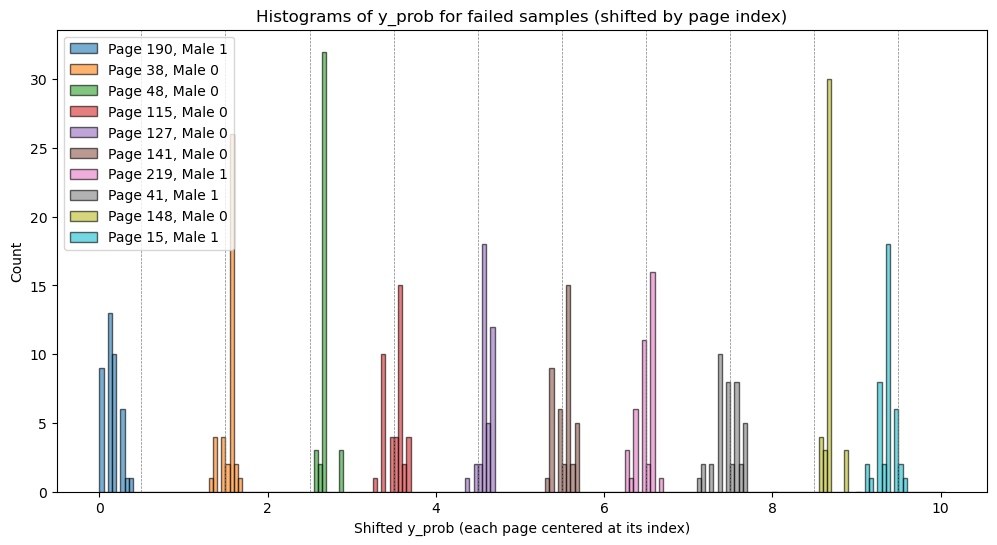

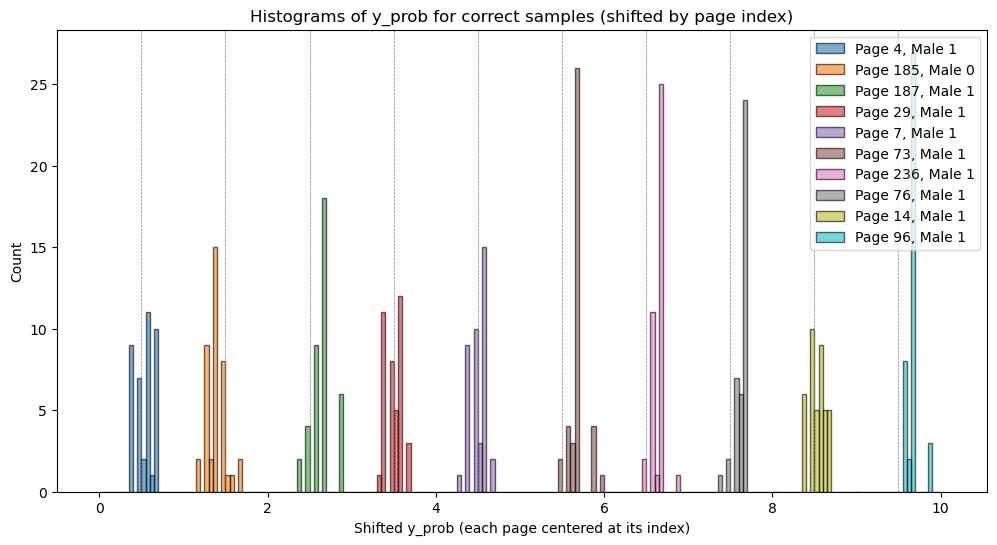

In [169]:
def display_pred_distribution(failed, failed_pages,num_pages=15,title='failed'):
    plt.figure(figsize=(12, 6))
    bin_width = 0.05
    np.random.shuffle(failed_pages)
    for i, page in enumerate(failed_pages[:num_pages]):
        subset = failed[failed['page'] == page]['y_prob']
        isMale = failed[failed['page'] == page]['grouped_true'].iloc[0]
        # Shift the histogram center by page number (e.g., offset by i)
        shifted = subset + i
        plt.hist(shifted, bins=np.arange(i, i + 1 + bin_width, bin_width), alpha=0.6, edgecolor='black', label=f'Page {page}, Male {isMale}')
        # Mark the center for each page
        plt.axvline(i + 0.5, color='gray', linestyle='--', linewidth=0.5)

    plt.title(f'Histograms of y_prob for {title} samples (shifted by page index)')
    plt.xlabel('Shifted y_prob (each page centered at its index)')
    plt.ylabel('Count')
    plt.legend()
    plt.savefig(os.path.join(search_dir, f"pred_distribution_{title}.png"))
    plt.show()
display_pred_distribution(failed, failed_pages,num_pages=10,title='failed')
display_pred_distribution(correct, correct['page'].unique(),num_pages=10,title='correct')

In [170]:
cols_to_drop = [c for c in res_df.columns if not(c.startswith('f') and len(c) > 1 and c[1].isdigit())]
print(f"Columns to drop: {cols_to_drop}")
c_of_interest=['page','male','y_pred','y_prob','grouped_true','weighted_vote','majority_vote','weighted_vote_uncertainty']
test = res_df[c_of_interest].copy()
display(test[test['page'] == 60])

Columns to drop: ['writer', 'isEng', 'same_text', 'file_name', 'male', 'Usage', 'x', 'y', 'x2', 'y2', 'n_cc', 'black_ratio', 'index', 'page', 'train', 'y_prob', 'y_pred', 'grouped_true', 'majority_vote', 'majority_vote_uncertainty', 'weighted_vote', 'weighted_vote_uncertainty', 'most_probable', 'most_probable_uncertainty', 'y_pred_writer', 'y_prob_writer']


,page,male,y_pred,y_prob,grouped_true,weighted_vote,majority_vote,weighted_vote_uncertainty
2400,60,0,0,0.264237,0,1,1,0.542037
2401,60,0,0,0.380176,0,1,1,0.542037
2402,60,0,1,0.681529,0,1,1,0.542037
2403,60,0,1,0.593967,0,1,1,0.542037
2404,60,0,0,0.488550,0,1,1,0.542037
2405,60,0,1,0.578014,0,1,1,0.542037
2406,60,0,0,0.462264,0,1,1,0.542037
2407,60,0,0,0.488550,0,1,1,0.542037
2408,60,0,1,0.634146,0,1,1,0.542037
2409,60,0,0,0.488550,0,1,1,0.542037


## descriptive statistics

In [171]:
res_df.columns

Index(['writer', 'isEng', 'same_text', 'file_name', 'male', 'Usage', 'x', 'y',
       'x2', 'y2', 'n_cc', 'black_ratio', 'index', 'page', 'train', 'y_prob',
       'y_pred', 'grouped_true', 'majority_vote', 'majority_vote_uncertainty',
       'weighted_vote', 'weighted_vote_uncertainty', 'most_probable',
       'most_probable_uncertainty', 'y_pred_writer', 'y_prob_writer'],
      dtype='object')

9760
9760
9760
9760
9760


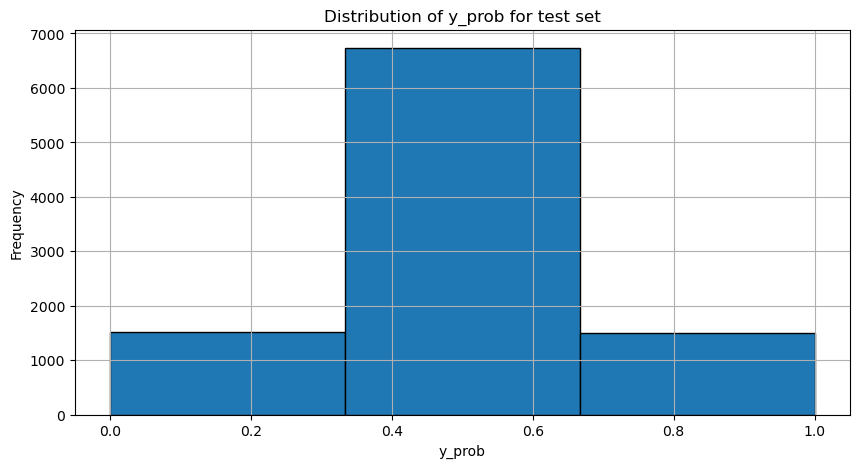

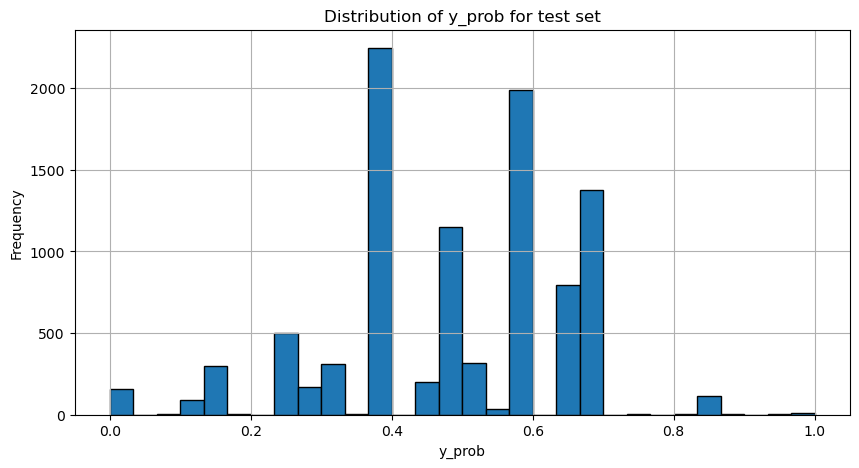

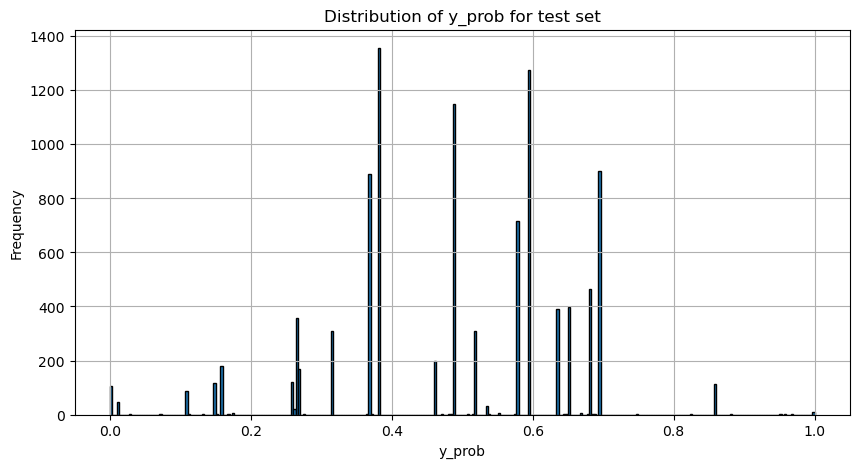

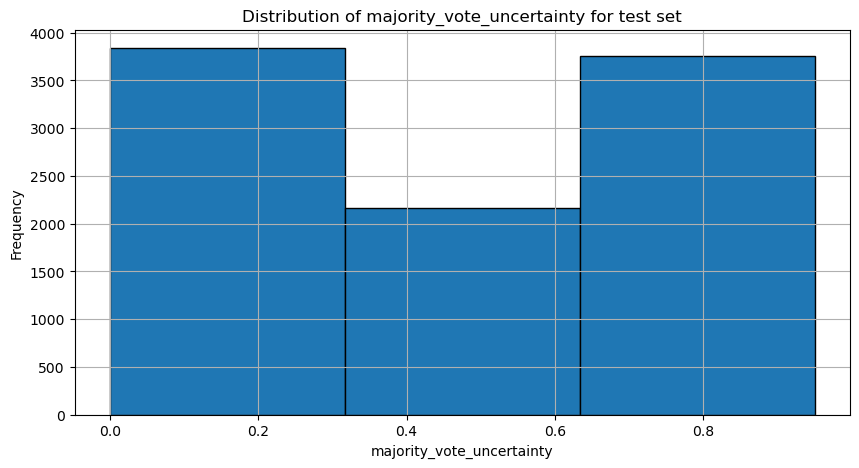

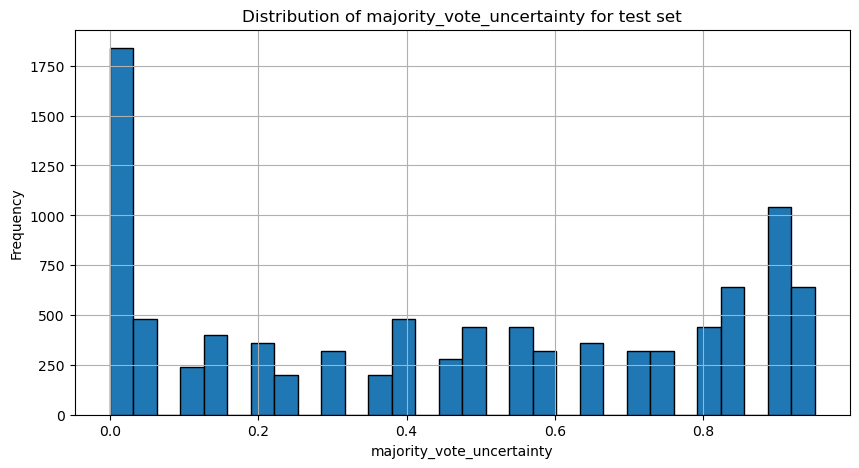

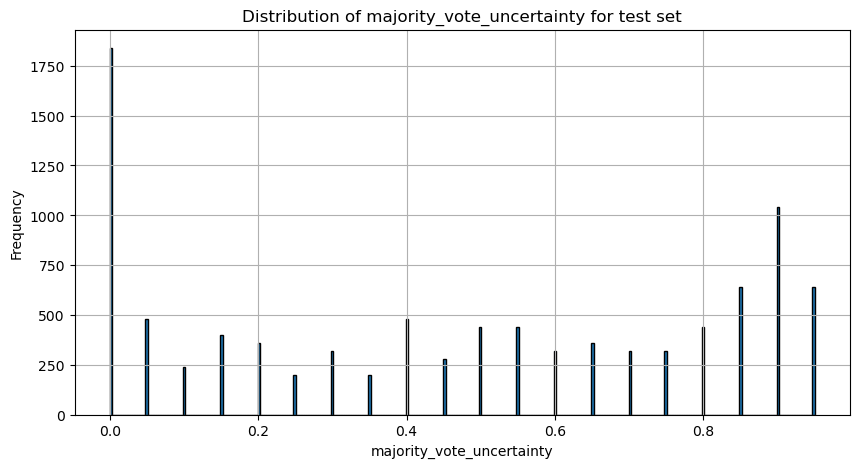

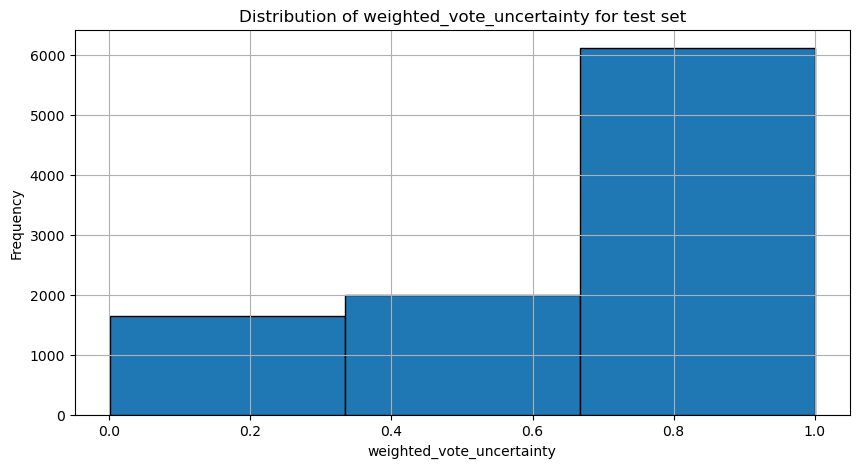

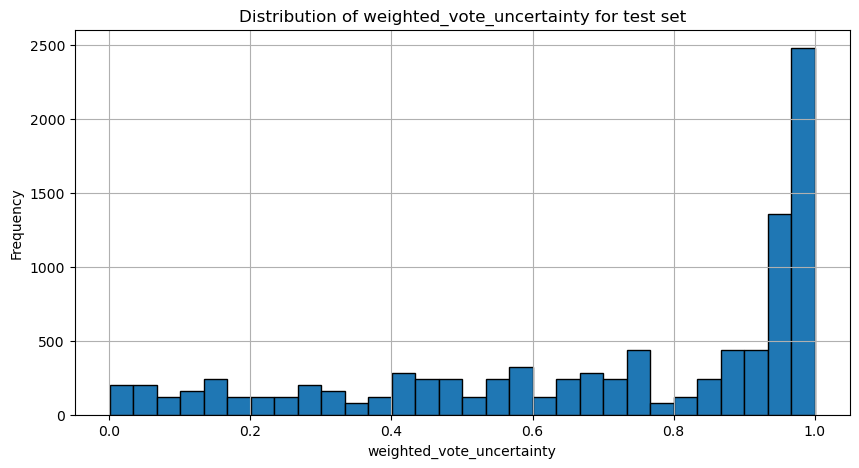

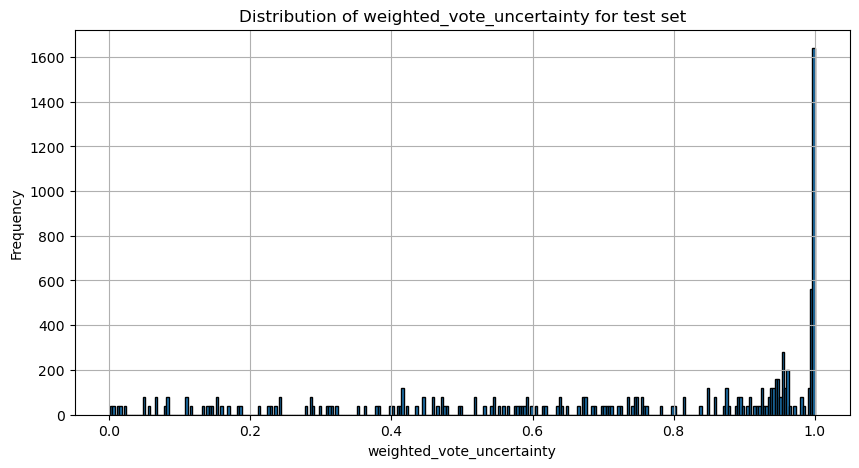

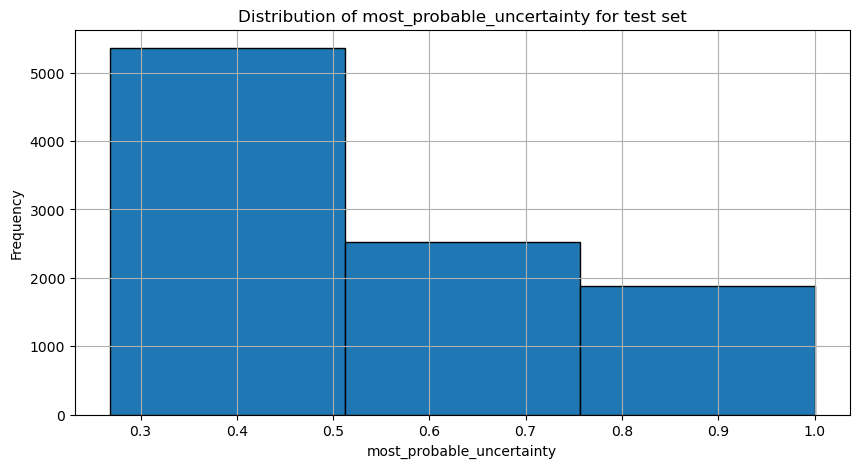

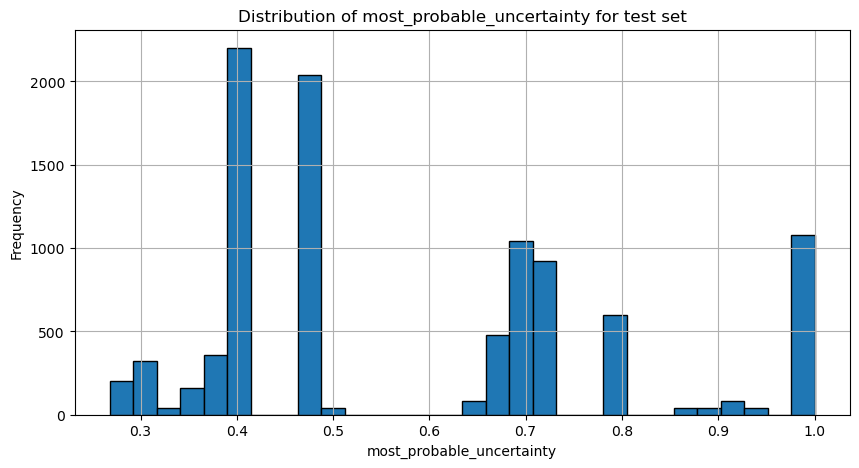

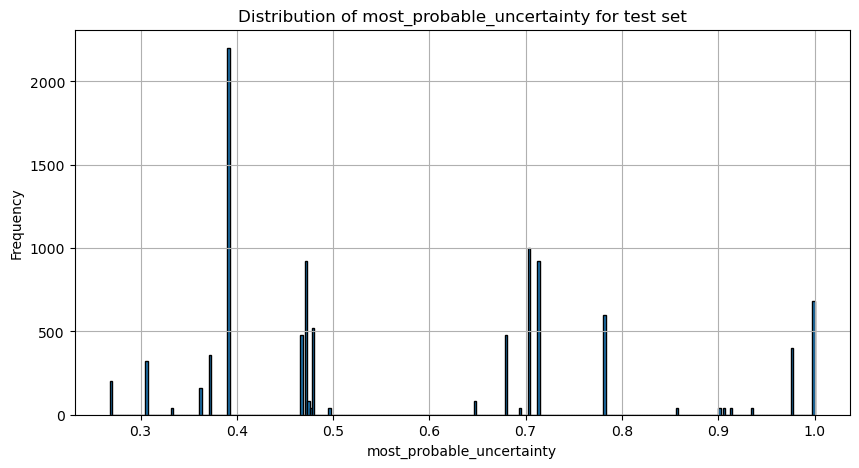

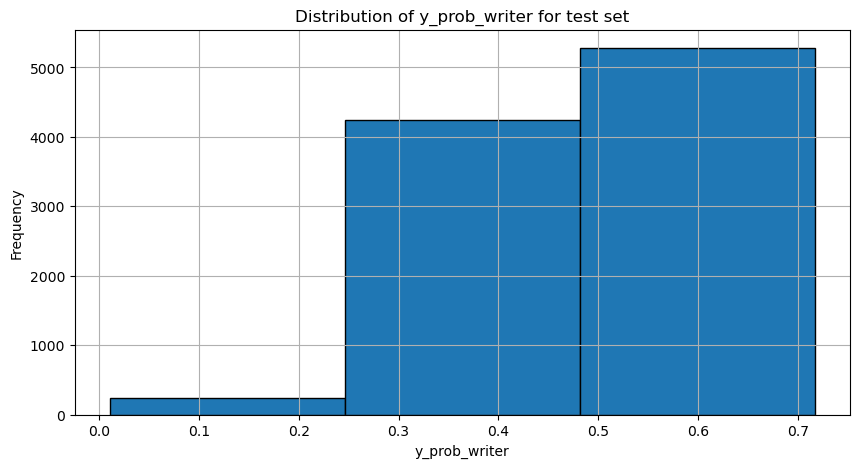

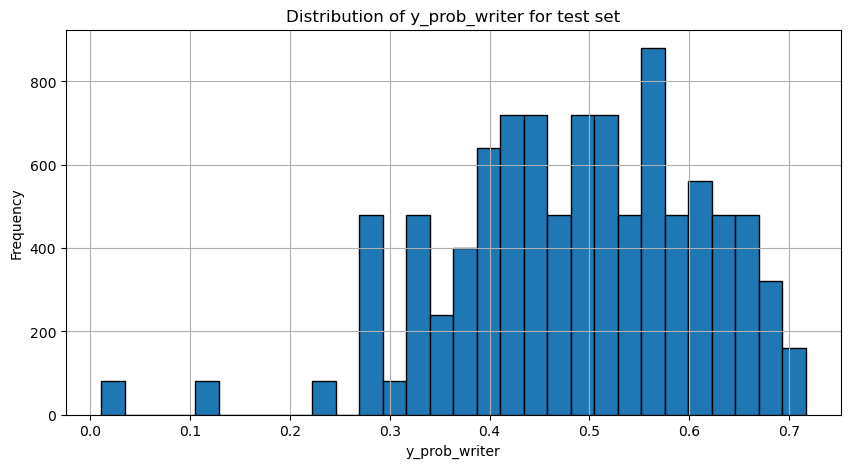

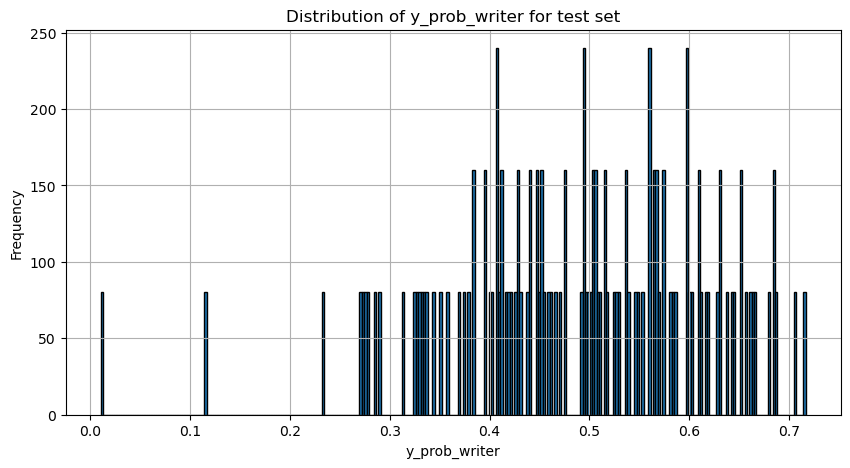

In [172]:
#probability distribution
import matplotlib.pyplot as plt
display_df=res_df[res_df['train']==0][['y_prob','majority_vote_uncertainty','weighted_vote_uncertainty','most_probable_uncertainty','y_prob_writer']].describe()
file_IO.save_df_to_png(display_df, os.path.join(search_dir, "uncertainty_table.png"))

def plot_prob_distribution(res_df,save_dir,prob_column='y_prob',bins=30):
    file_IO.access_or_create_dir(save_dir)
    plt.figure(figsize=(10, 5))
    res_df[res_df['train']==0][prob_column].hist(bins=bins, edgecolor='black')
    plt.title(f'Distribution of {prob_column} for test set')
    plt.xlabel(prob_column)
    plt.ylabel('Frequency')
    plt.savefig(os.path.join(save_dir, f"{prob_column}_prob_distribution_nbins_{bins}.png"))
    #plt.show()
prob_columns = ['y_prob','majority_vote_uncertainty','weighted_vote_uncertainty','most_probable_uncertainty','y_prob_writer']
for p_column in prob_columns:
    #temp_df=res_df.groupby('page').first()
    temp_df=res_df.copy()
    print(len(temp_df))
    for i in range(3):
        plot_prob_distribution(temp_df,save_dir=search_dir+'prob_distribution/', prob_column=p_column, bins=3*10**i)

In [173]:
#TPR=Recall=TP/(TP + FN)
#FPR=FP/(FP + TN)

# Sample confusion matrix
labels = ['female', 'male']

# confusion matrix page level
grouped_res = res_df[res_df['train']==0].groupby('page').first()
true_values = grouped_res['grouped_true']



save_dir = search_dir+'confusion_matrices/'
save_dir_2 = search_dir+'roc_auc/'
save_dir_3 = search_dir+'calibration_curves/'
file_IO.access_or_create_dir(save_dir)
file_IO.access_or_create_dir(save_dir_2)
file_IO.access_or_create_dir(save_dir_3)
for metric in list_of_metrics:
    pred_values = grouped_res[metric]
    prob_values = grouped_res[f'{metric}_uncertainty']
    for i,p in enumerate(prob_values): #some values in weighted uncertainty are >1
        if p>1:
            prob_values[i] = 1
    plot_confusion_matrix(true_values, pred_values, save_dir, label_names=labels, labels=[0,1], level='page', metric=metric)
    roc_auc(true_values, prob_values, save_dir_2, level='page', metric=metric)
    plot_calibration_with_metrics(
        true_values,
        prob_values,
        n_bins=10,
        pos_label=1,
        title="Calibration Curves (Uncalibrated vs Isotonic)",
        save_path=save_dir_3,
        show=False,
        level='patch', 
        metric=metric
    )

# confusion matrix patch level
grouped_res = res_df[res_df['train']==0]
true_values = grouped_res['grouped_true']
pred_values = grouped_res['y_pred']
prob_values = grouped_res['y_prob']
plot_confusion_matrix(true_values, pred_values, save_dir, label_names=labels, labels=[0,1], level='patch', metric='individual')
roc_auc(true_values, prob_values, save_dir_2, level='patch', metric='individual')
plot_calibration_with_metrics(
    true_values,
    prob_values,
    n_bins=10,
    pos_label=1,
    title="Calibration Curves (Uncalibrated vs Isotonic)",
    save_path=save_dir_3,
    show=False,
    level='patch',
    metric='individual'
)

# confusion matrix writer
grouped_res = res_df[res_df['train']==0].groupby('writer').first()
true_values = grouped_res['grouped_true']
pred_values = grouped_res['y_pred_writer']
prob_values = grouped_res['y_prob_writer']
plot_confusion_matrix(true_values, pred_values, save_dir, label_names=labels, labels=[0,1], level='writer', metric='average')
roc_auc(true_values, prob_values, save_dir_2, level='writer', metric='average')
plot_calibration_with_metrics(
    true_values,
    prob_values,
    n_bins=10,
    pos_label=1,
    title="Calibration Curves (Uncalibrated vs Isotonic)",
    save_path=save_dir_3,
    show=False,
    level='writer',
    metric='average'
)


(<Figure size 1200x600 with 2 Axes>,
 array([<Axes: title={'center': 'Uncalibrated'}, xlabel='Predicted Probability', ylabel='True Probability'>,
        <Axes: title={'center': 'Isotonic-calibrated'}, xlabel='Predicted Probability', ylabel='True Probability'>],
       dtype=object))

## misclassified samples (images)

In [39]:
class_split_page = evaluation_utils.group_instances(res_df,level='page',list_of_metrics=list_of_metrics)
print(class_split_page.columns)
class_split_patch = evaluation_utils.group_instances(res_df,level='patch',list_of_metrics=list_of_metrics)
print(class_split_patch.columns)

Index(['writer', 'isEng', 'same_text', 'file_name', 'male', 'Usage', 'x', 'y',
       'x2', 'y2', 'n_cc', 'black_ratio', 'index', 'page', 'train', 'y_prob',
       'y_pred', 'grouped_true', 'majority_vote', 'majority_vote_uncertainty',
       'weighted_vote', 'weighted_vote_uncertainty', 'most_probable',
       'most_probable_uncertainty', 'y_pred_writer', 'y_prob_writer',
       'majority_vote_selected', 'majority_vote_sure', 'majority_vote_unsure',
       'majority_vote_ok', 'weighted_vote_selected', 'weighted_vote_sure',
       'weighted_vote_unsure', 'weighted_vote_ok', 'most_probable_selected',
       'most_probable_sure', 'most_probable_unsure', 'most_probable_ok'],
      dtype='object')
Index(['writer', 'isEng', 'same_text', 'file_name', 'male', 'Usage', 'x', 'y',
       'x2', 'y2', 'n_cc', 'black_ratio', 'index', 'page', 'train', 'y_prob',
       'y_pred', 'grouped_true', 'majority_vote', 'majority_vote_uncertainty',
       'weighted_vote', 'weighted_vote_uncertainty', 'most_pr

In [40]:
unsure_ok_true = evaluation_utils.select_instances(class_split_page, metric='weighted_vote', sure=0, unsure=1, ok=1,true=1, n_samples=1)

## select instances

In [41]:
selected = evaluation_utils.select_for_explanation(class_split_page, selected_metric)

,majority_vote_sure,majority_vote_unsure,majority_vote_ok,grouped_true
page,,,,
38,0,0,0,0
15,0,0,0,1
47,0,0,1,0
83,0,0,1,1
114,0,1,0,0
142,0,1,1,0
227,0,1,1,1
210,1,0,0,0
204,1,0,0,1


In [42]:
selected_pages=list(selected['page'])
all_selected_patches=class_split_page[class_split_page['page'].isin(selected_pages)]

In [43]:
all_selected_patches.to_csv(search_dir+f'selected_instances_{selected_metric}.csv', index=False)

In [44]:
len(selected)

11

# reload

In [2]:
def reload_modules():
    import importlib
    import utils.data_loading as data_loading
    import utils.visualization as visualization
    import utils.dataframes as dataframes
    import utils.utils_transforms as u_transforms
    import utils.training_utils as training_utils
    import utils.model_utils as model_utils
    import utils.file_IO as file_IO
    import utils.vit_rollout_mod as vit_rollout_mod
    import utils.evaluation_utils as evaluation_utils
    import utils.script_launching as script_launching
    
    importlib.reload(file_IO)
    importlib.reload(data_loading)
    importlib.reload(visualization)
    importlib.reload(dataframes)
    importlib.reload(u_transforms)
    importlib.reload(model_utils)
    importlib.reload(training_utils)
    importlib.reload(vit_rollout_mod)
    importlib.reload(evaluation_utils)
    importlib.reload(script_launching)

    return data_loading, visualization, dataframes, u_transforms, training_utils, model_utils, file_IO, vit_rollout_mod, evaluation_utils, script_launching
data_loading, visualization, dataframes, u_transforms, training_utils, model_utils, file_IO, vit_rollout_mod, evaluation_utils, script_launching = reload_modules()

In [3]:
def plot_calibration_with_metrics(
    true_values,
    prob_values,
    n_bins=10,
    pos_label=1,
    title="Calibration Curves (Uncalibrated vs Isotonic)",
    save_path=None,
    show=True,
    level='patch',metric='average'
):
    """
    Plots side-by-side calibration diagrams for:
      - Uncalibrated probabilities
      - Isotonic-calibrated probabilities

    Also stamps Brier scores and Acc@0.5 for both on the same figure.

    Parameters
    ----------
    true_values : array-like of shape (n_samples,)
        Ground-truth binary labels (0/1). Ensure 'pos_label' matches the positive class.
    prob_values : array-like of shape (n_samples,)
        Predicted probabilities for the positive class.
    n_bins : int, default=10
        Number of bins for reliability diagram.
    pos_label : int or str, default=1
        Positive class label (used by Brier score).
    title : str
        Suptitle for the figure.
    save_path : str or None
        If provided, saves the figure to this path.
    show : bool
        If True, calls plt.show() at the end.

    Returns
    -------
    fig, axes
    """
    y = np.asarray(true_values)
    p = np.asarray(prob_values, dtype=float)

    # Drop NaNs in probabilities (keep alignment)
    mask = ~np.isnan(p)
    y, p = y[mask], p[mask]

    # --- Uncalibrated ---
    pt_u, pp_u = calibration_curve(y, p, n_bins=n_bins)
    brier_u = brier_score_loss(y, p, pos_label=pos_label)
    acc_u   = accuracy_score(y, (p >= 0.5).astype(int))

    # --- Isotonic-calibrated ---
    iso = IsotonicRegression(out_of_bounds='clip')
    iso.fit(p, y)
    p_cal = iso.predict(p)

    pt_c, pp_c = calibration_curve(y, p_cal, n_bins=n_bins)
    brier_c = brier_score_loss(y, p_cal, pos_label=pos_label)
    acc_c   = accuracy_score(y, (p_cal >= 0.5).astype(int))

    # --- Figure ---
    fig, axes = plt.subplots(1, 2, figsize=(12, 6), sharex=True, sharey=True)
    for ax, pp, pt, subtitle in [
        (axes[0], pp_u, pt_u, "Uncalibrated"),
        (axes[1], pp_c, pt_c, "Isotonic-calibrated"),
    ]:
        ax.plot(pp, pt, marker='o', label='Model')
        ax.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Perfectly calibrated')
        ax.set_xlabel('Predicted Probability')
        ax.set_ylabel('True Probability')
        ax.set_title(subtitle)
        ax.grid(True)
    axes[0].legend(loc='upper left')
    fig.suptitle(title, y=0.98)

    # --- “prints” embedded as a textbox ---
    text = (
        f"Brier (uncal.): {brier_u:.4f}   Acc@0.5 (uncal.): {acc_u:.4f}\n"
        f"Brier (cal.):   {brier_c:.4f}   Acc@0.5 (cal.):   {acc_c:.4f}\n"
        f"n={len(y)}, bins={n_bins}, positive label={pos_label}"
    )
    fig.subplots_adjust(bottom=0.22)
    fig.text(
        0.5, 0.03, text,
        ha='center', va='bottom', fontsize=10,
        family='monospace',
        bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='0.8', alpha=0.95)
    )

    if save_path:
        fig.savefig(save_path+f'{level}_calibration_curve_{metric}.png', dpi=200, bbox_inches='tight')
    if show:
        plt.show()
    else:
        plt.close(fig)

    return fig, axes


def plot_confusion_matrix(
    true_values,
    pred_values,
    save_dir,
    label_names=None,   # e.g., ['female','male']
    labels=None,        # e.g., [0, 1]
    level='page',
    metric='individual'
):
    import os, numpy as np, matplotlib.pyplot as plt, seaborn as sns
    from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, balanced_accuracy_score
    from sklearn.utils.multiclass import unique_labels

    # Defaults if not provided
    if labels is None:
        labels = unique_labels(true_values, pred_values)
    if label_names is None:
        label_names = [str(x) for x in labels]
    else:
        label_names = [str(x) for x in label_names]

    # Confusion matrix (fixed order)
    conf = confusion_matrix(true_values, pred_values, labels=labels)

    # Totals
    row_sums = conf.sum(axis=1, keepdims=True)
    col_sums = conf.sum(axis=0, keepdims=True)
    total = conf.sum() if conf.size else 0

    # Extended matrix with totals
    conf_ext = np.vstack([conf, col_sums])
    conf_ext = np.hstack([conf_ext, np.append(row_sums, total).reshape(-1, 1)])

    # Percentages of total (guard divide-by-zero)
    conf_ext_percent = (conf_ext / total * 100) if total else np.zeros_like(conf_ext, dtype=float)

    # Annotations
    annot = np.empty_like(conf_ext, dtype=object)
    for i in range(conf_ext.shape[0]):
        for j in range(conf_ext.shape[1]):
            count = int(conf_ext[i, j])
            percent = conf_ext_percent[i, j]
            annot[i, j] = f'{percent:.1f}%\n({count})'

    # Ticks
    xticks = list(label_names) + ['Total']
    yticks = list(label_names) + ['Total']

    # Figure
    fig, ax = plt.subplots(figsize=(10, 10))
    sns.heatmap(
        conf_ext_percent, annot=annot, fmt='',
        cmap='Blues', xticklabels=xticks, yticklabels=yticks,
        cbar_kws={"label": "% of all samples"}, ax=ax
    )
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    ax.set_title(f"Confusion Matrix with Totals — {level} / {metric}")

    # Text block (use correct names + labels)
    report_str = classification_report(
        true_values, pred_values,
        labels=labels, target_names=label_names,
        digits=4, zero_division=0
    )
    acc = accuracy_score(true_values, pred_values)
    bacc = balanced_accuracy_score(true_values, pred_values)

    text_block = (
        "Classification report:\n"
        f"{report_str}\n"
        f"Accuracy: {acc:.4f}\n"
        f"Balanced Accuracy: {bacc:.4f}"
    )

    fig.subplots_adjust(bottom=0.35)
    fig.text(0.01, 0.02, text_block, ha='left', va='bottom', family='monospace', fontsize=9)

    os.makedirs(save_dir, exist_ok=True)
    out_path = os.path.join(save_dir, f"{level}_confusion_matrix_{metric}.png")
    fig.savefig(out_path, dpi=200, bbox_inches='tight')
    plt.close(fig)

def roc_auc(true_values, prob_values, save_dir, level='page', metric='individual'):
    fpr, tpr, thresholds = roc_curve(true_values, prob_values)
    roc_auc = auc(fpr, tpr)
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, color='blue', label=f'ROC curve (area = {roc_auc:.4f})')
    plt.plot([0, 1], [0, 1], color='red', linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic (ROC) Curve')
    plt.legend(loc='lower right')
    out_path = os.path.join(save_dir, f"{level}_roc_curve_{metric}.png")
    plt.savefig(out_path, dpi=200, bbox_inches='tight')
    plt.close()